In [1]:
import mlflow
import pandas as pd

import warnings

warnings.filterwarnings('ignore')

In [2]:
EXPERIMENT_NAME = 'churn-eda'

mlflow.set_tracking_uri("sqlite:///../data/mlflow/churn_experiments.db")
# mlflow.create_experiment(EXPERIMENT_NAME)

In [3]:
df = pd.read_csv('../data/dataset/telco_customer_churn.csv')
print(df.head())
print(df.shape)

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [4]:
# Exploração Inicial dos Dados
print("=" * 80)
print("INFORMAÇÕES DO DATASET")
print("=" * 80)
print(f"\nForma do dataset: {df.shape}")
print(f"\nTipos de dados:\n{df.dtypes}")
print(f"\nValores faltantes:\n{df.isnull().sum()}")
print(f"\nEstatísticas descritivas:\n{df.describe()}")
print(f"\nPrimeiras linhas:\n{df.head(10)}")


INFORMAÇÕES DO DATASET

Forma do dataset: (7043, 21)

Tipos de dados:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Valores faltantes:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0


In [5]:
# Importar bibliotecas para visualização e preparação de dados
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Configurar estilo dos gráficos
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)



ANÁLISE DA VARIÁVEL ALVO

Colunas do dataset:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Coluna de Churn: Churn

Distribuição de Churn:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Proporção de Churn:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


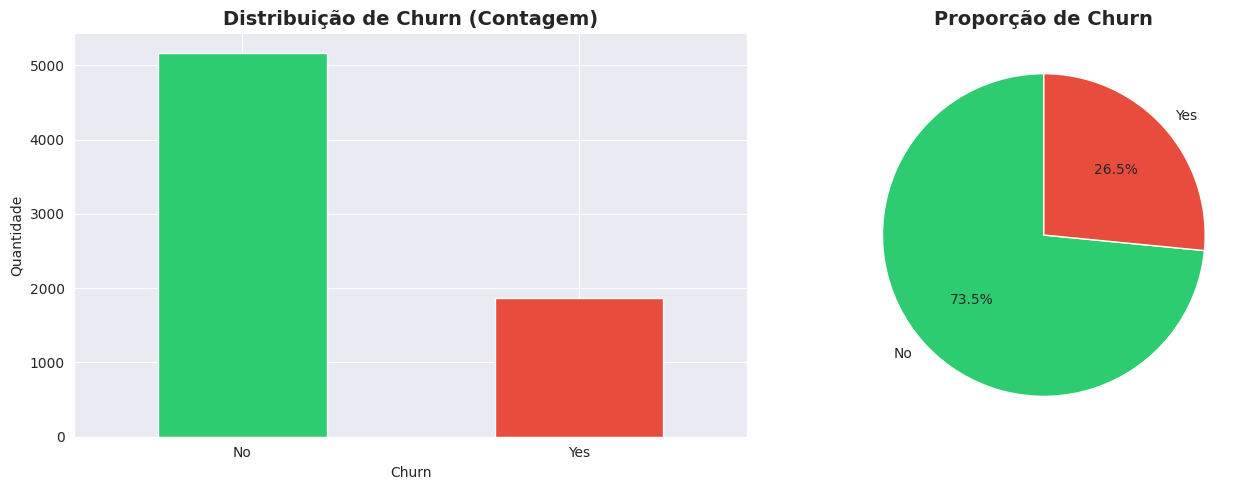

In [6]:
# Análise da Variável Alvo (Churn)
print("\n" + "=" * 80)
print("ANÁLISE DA VARIÁVEL ALVO")
print("=" * 80)

# Verificar coluna de churn
print(f"\nColunas do dataset:\n{df.columns.tolist()}")

# Identificar coluna de churn (pode variar)
churn_col = 'Churn' if 'Churn' in df.columns else [col for col in df.columns if 'churn' in col.lower()][0]
print(f"\nColuna de Churn: {churn_col}")
print(f"\nDistribuição de Churn:\n{df[churn_col].value_counts()}")
print(f"\nProporção de Churn:\n{df[churn_col].value_counts(normalize=True) * 100}")

# Visualizar proporção de churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
df[churn_col].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribuição de Churn (Contagem)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Quantidade')
axes[0].tick_params(axis='x', rotation=0)

# Gráfico de pizza
df[churn_col].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                   colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Proporção de Churn', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()



ANÁLISE DE VARIÁVEIS

Colunas Numéricas (3): ['SeniorCitizen', 'tenure', 'MonthlyCharges']

Colunas Categóricas (18): ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


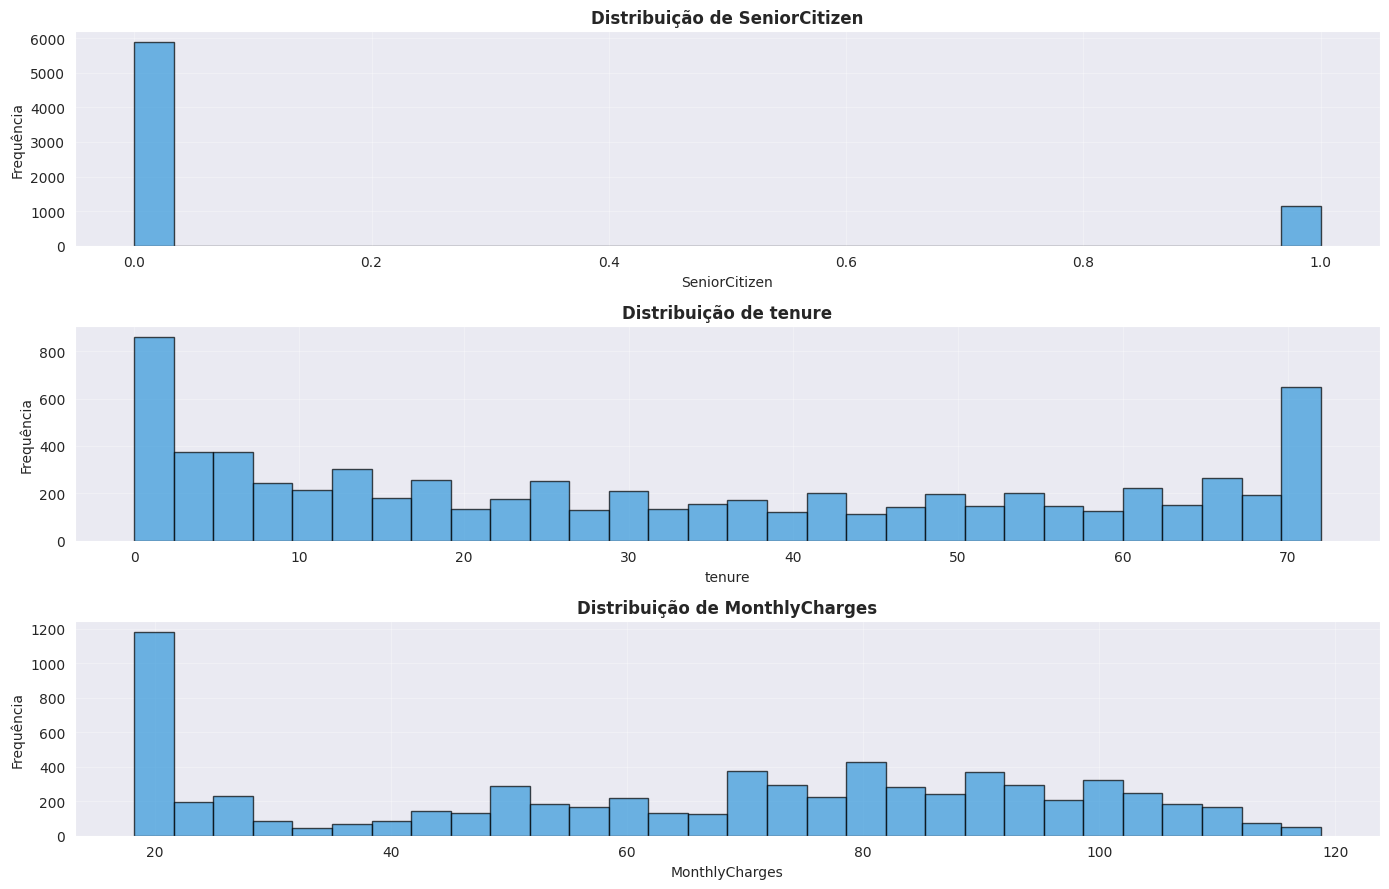

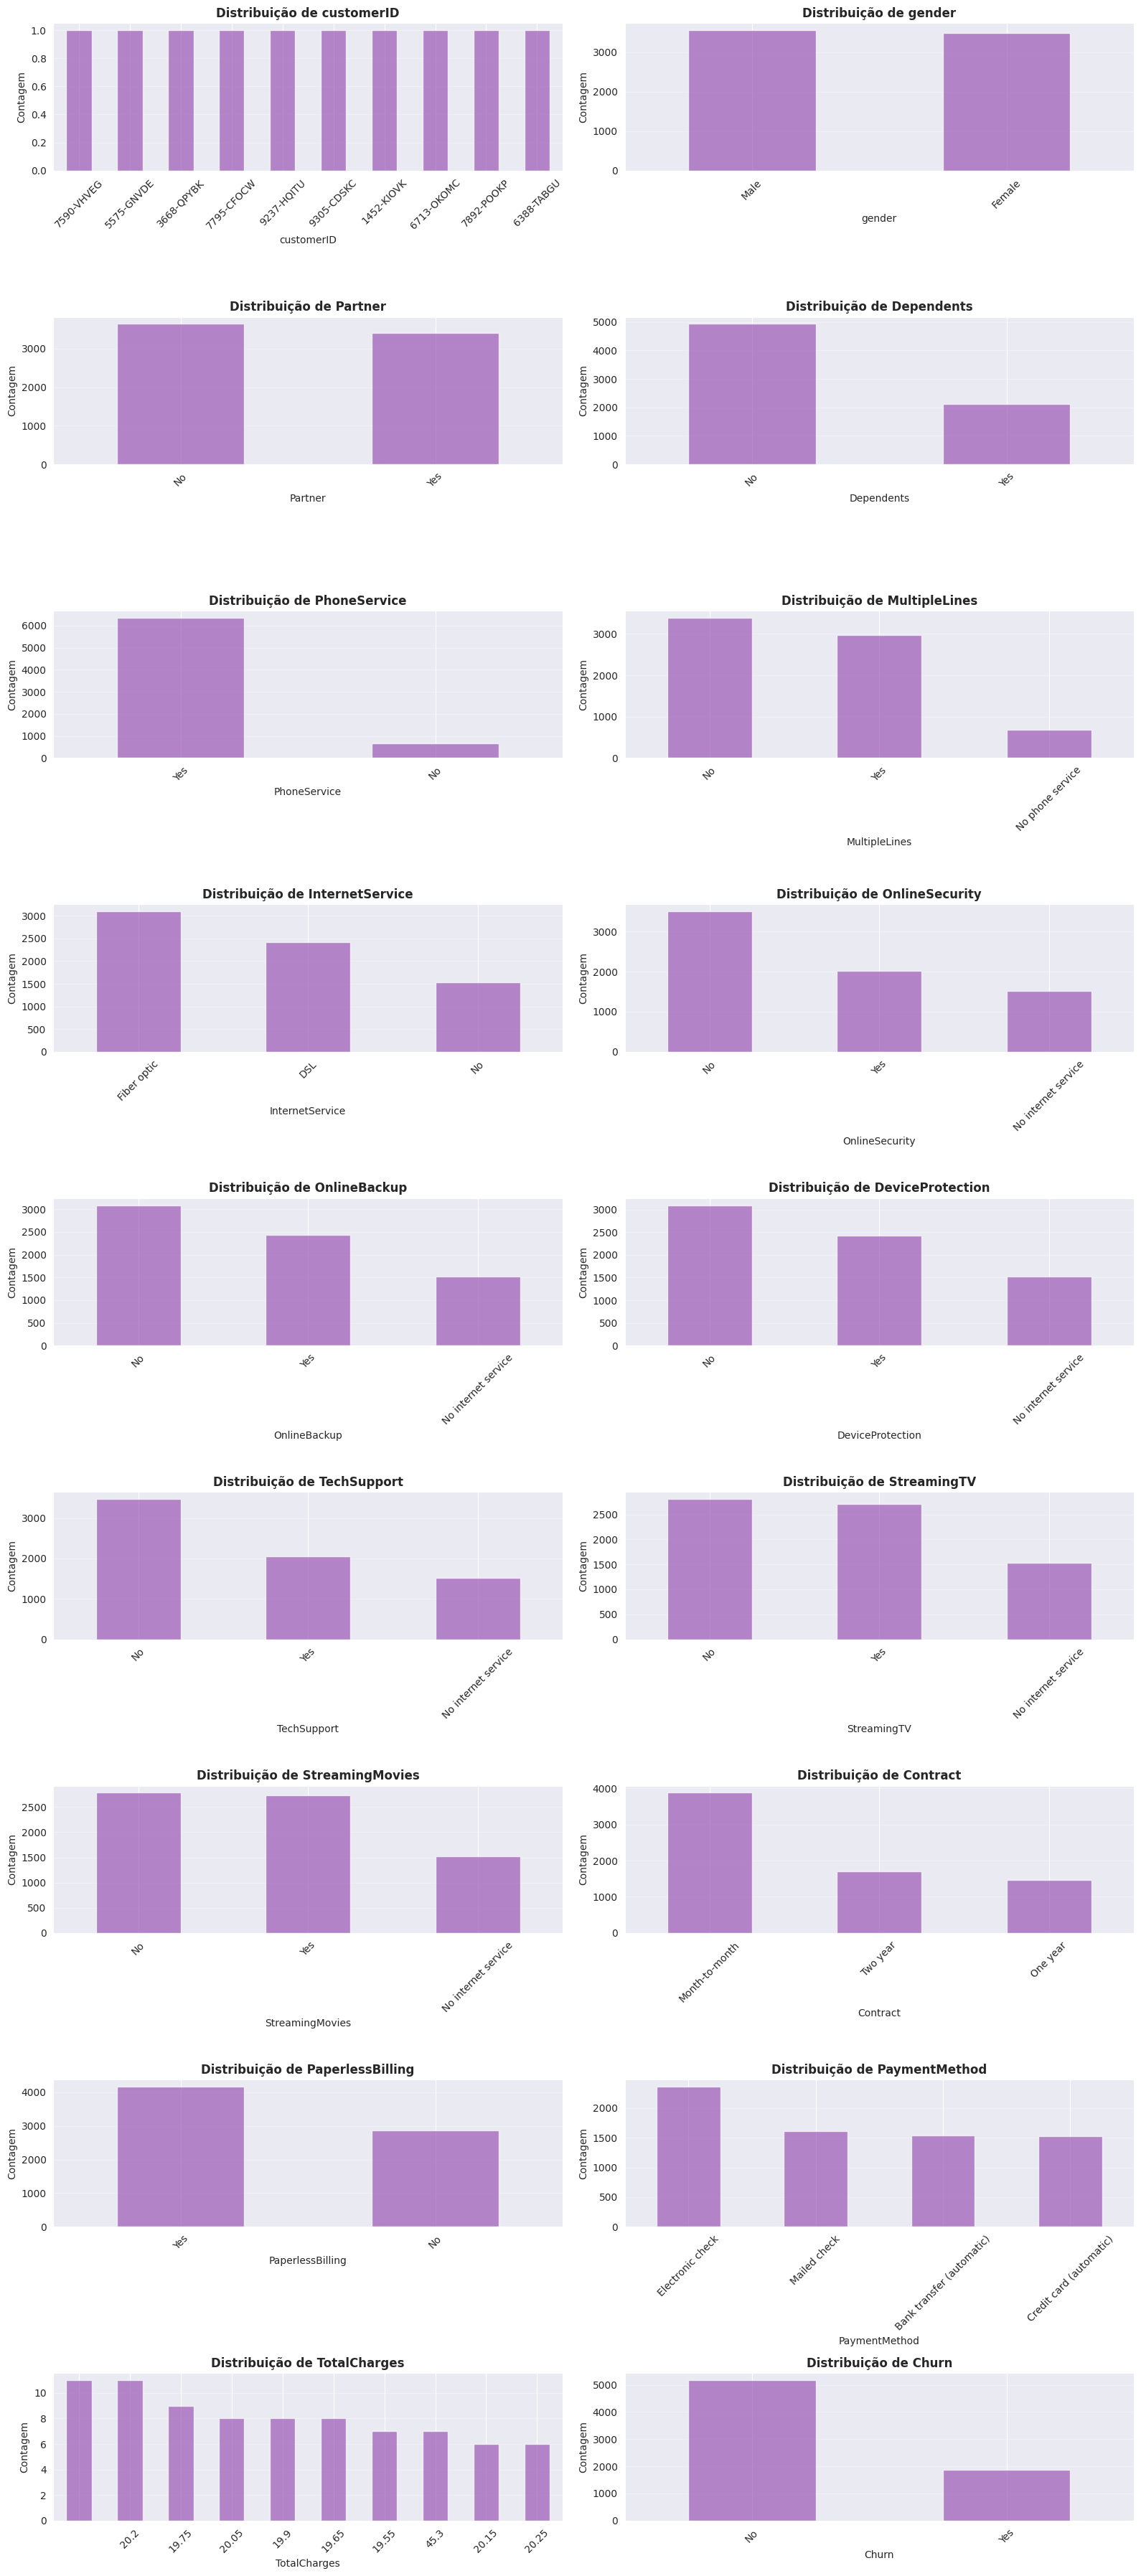

In [7]:
# Separar colunas numéricas e categóricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("\n" + "=" * 80)
print("ANÁLISE DE VARIÁVEIS")
print("=" * 80)
print(f"\nColunas Numéricas ({len(numeric_cols)}): {numeric_cols}")
print(f"\nColunas Categóricas ({len(categorical_cols)}): {categorical_cols}")

# Visualizar distribuição de variáveis numéricas
fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(14, 3 * len(numeric_cols)))
if len(numeric_cols) == 1:
    axes = [axes]

for idx, col in enumerate(numeric_cols):
    axes[idx].hist(df[col], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribuição de {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequência')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Visualizar distribuição de variáveis categóricas
fig, axes = plt.subplots((len(categorical_cols) + 1) // 2, 2, figsize=(16, 4 * ((len(categorical_cols) + 1) // 2)))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    top_values = df[col].value_counts().head(10)
    top_values.plot(kind='bar', ax=axes[idx], color='#9b59b6', alpha=0.7)
    axes[idx].set_title(f'Distribuição de {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Contagem')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(True, alpha=0.3, axis='y')

# Remover subplots vazios
for idx in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()



ANÁLISE DE CORRELAÇÃO

Matriz de Correlação:
                SeniorCitizen    tenure  MonthlyCharges
SeniorCitizen        1.000000  0.016567        0.220173
tenure               0.016567  1.000000        0.247900
MonthlyCharges       0.220173  0.247900        1.000000


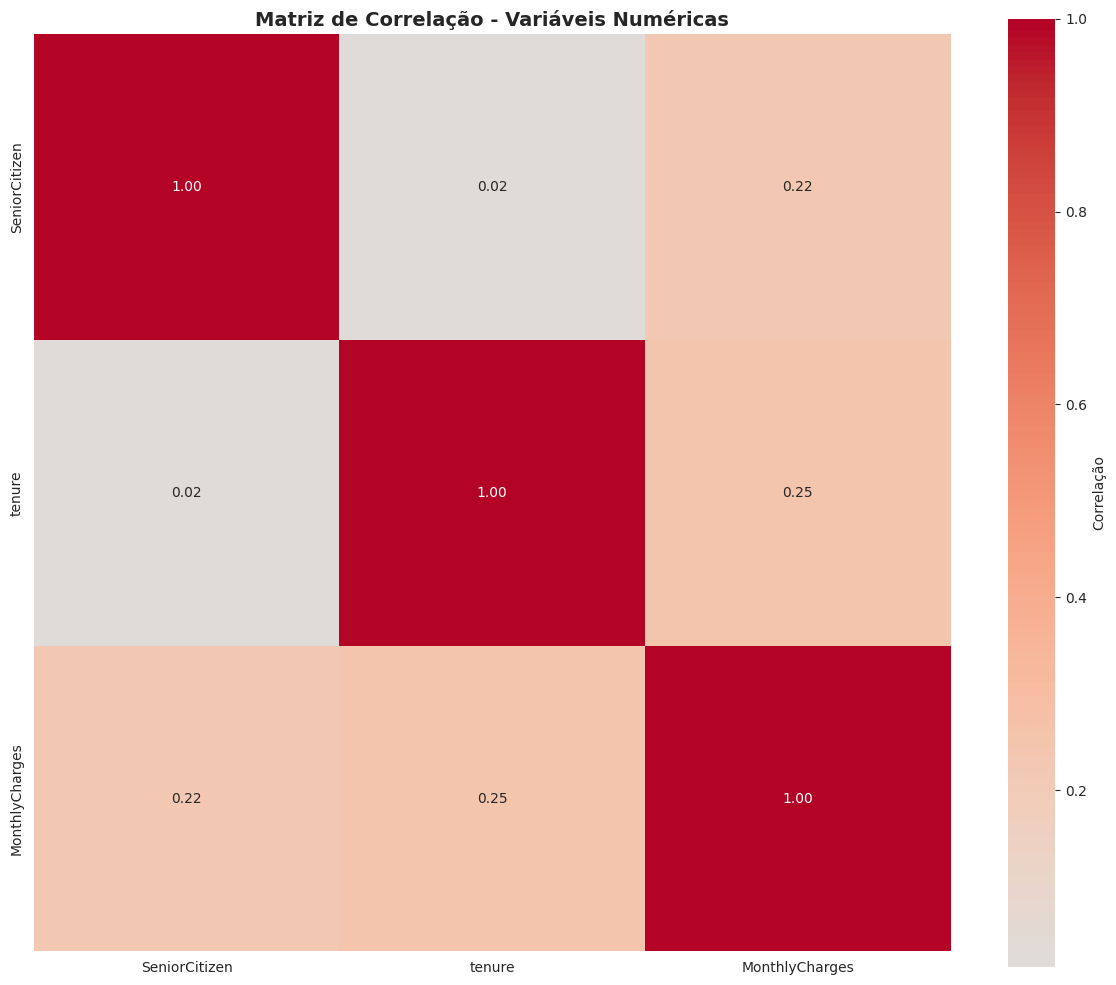


RELAÇÃO COM CHURN (Variáveis Numéricas)


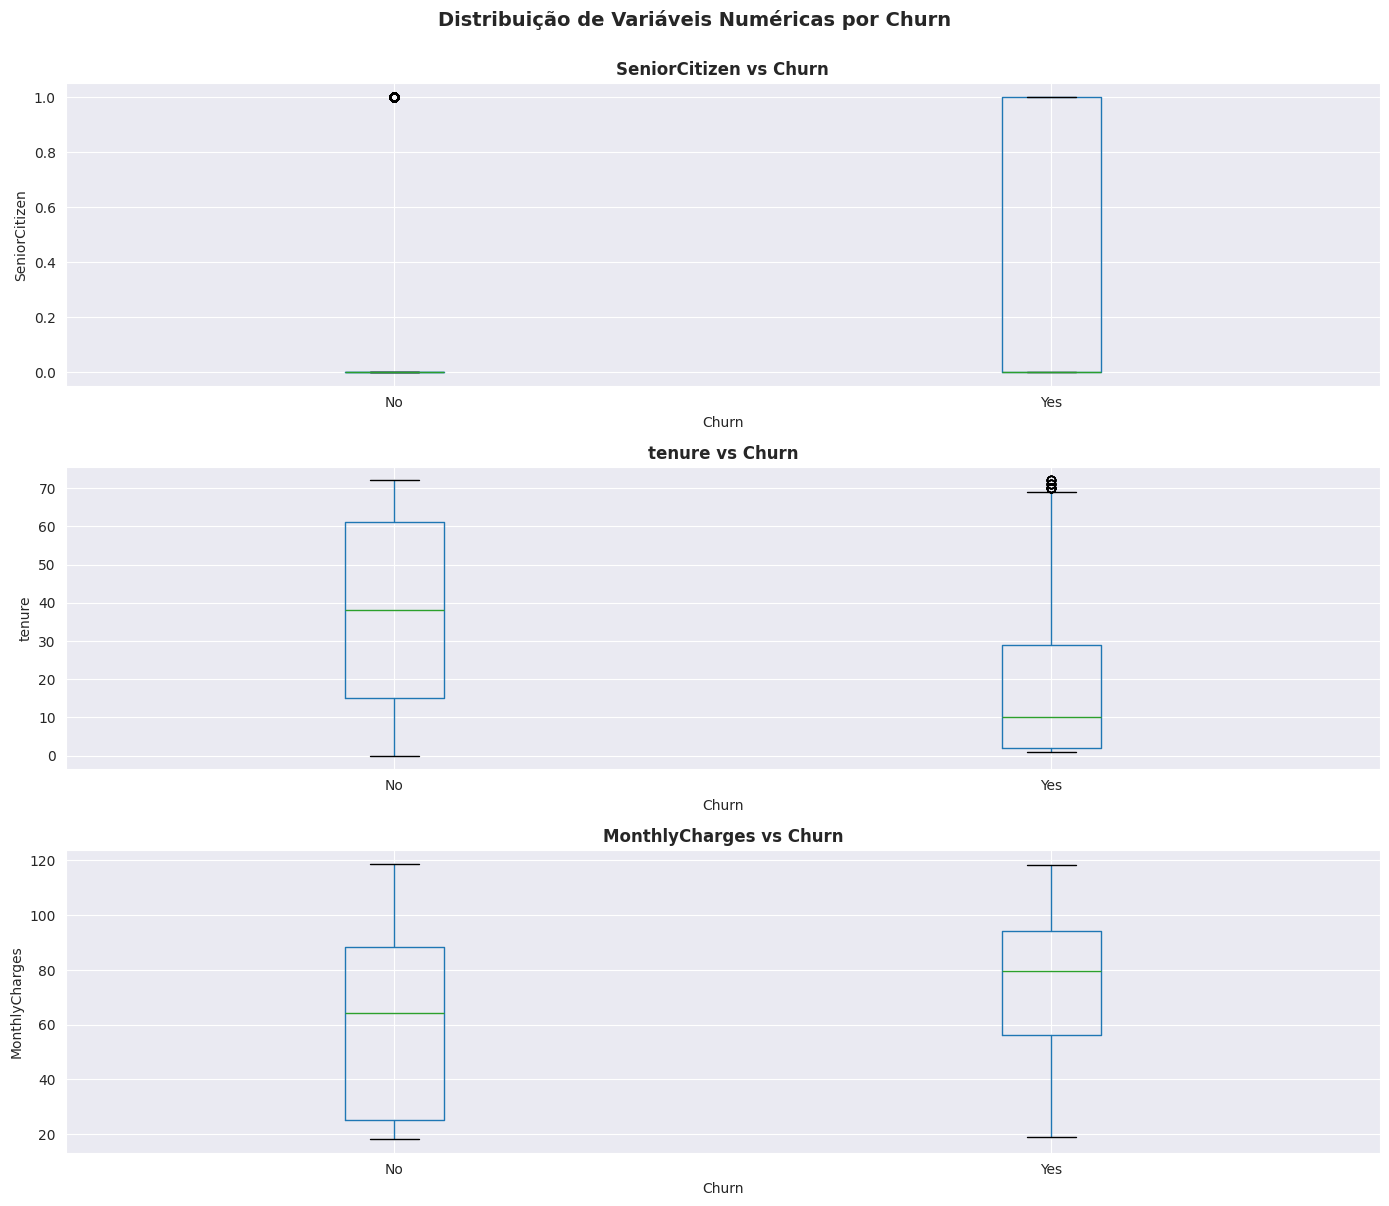

In [8]:
# Correlação entre variáveis numéricas
print("\n" + "=" * 80)
print("ANÁLISE DE CORRELAÇÃO")
print("=" * 80)

correlation_matrix = df[numeric_cols].corr()
print(f"\nMatriz de Correlação:\n{correlation_matrix}")

# Visualizar matriz de correlação
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, cbar_kws={'label': 'Correlação'})
plt.title('Matriz de Correlação - Variáveis Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Analisar relação com Churn para variáveis numéricas
print("\n" + "=" * 80)
print("RELAÇÃO COM CHURN (Variáveis Numéricas)")
print("=" * 80)

fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(14, 4 * len(numeric_cols)))
if len(numeric_cols) == 1:
    axes = [axes]

for idx, col in enumerate(numeric_cols):
    df.boxplot(column=col, by=churn_col, ax=axes[idx])
    axes[idx].set_title(f'{col} vs {churn_col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(churn_col)
    axes[idx].set_ylabel(col)
    
plt.suptitle('Distribuição de Variáveis Numéricas por Churn', fontsize=14, fontweight='bold', y=1.001)
plt.tight_layout()
plt.show()



RELAÇÃO COM CHURN (Variáveis Categóricas)


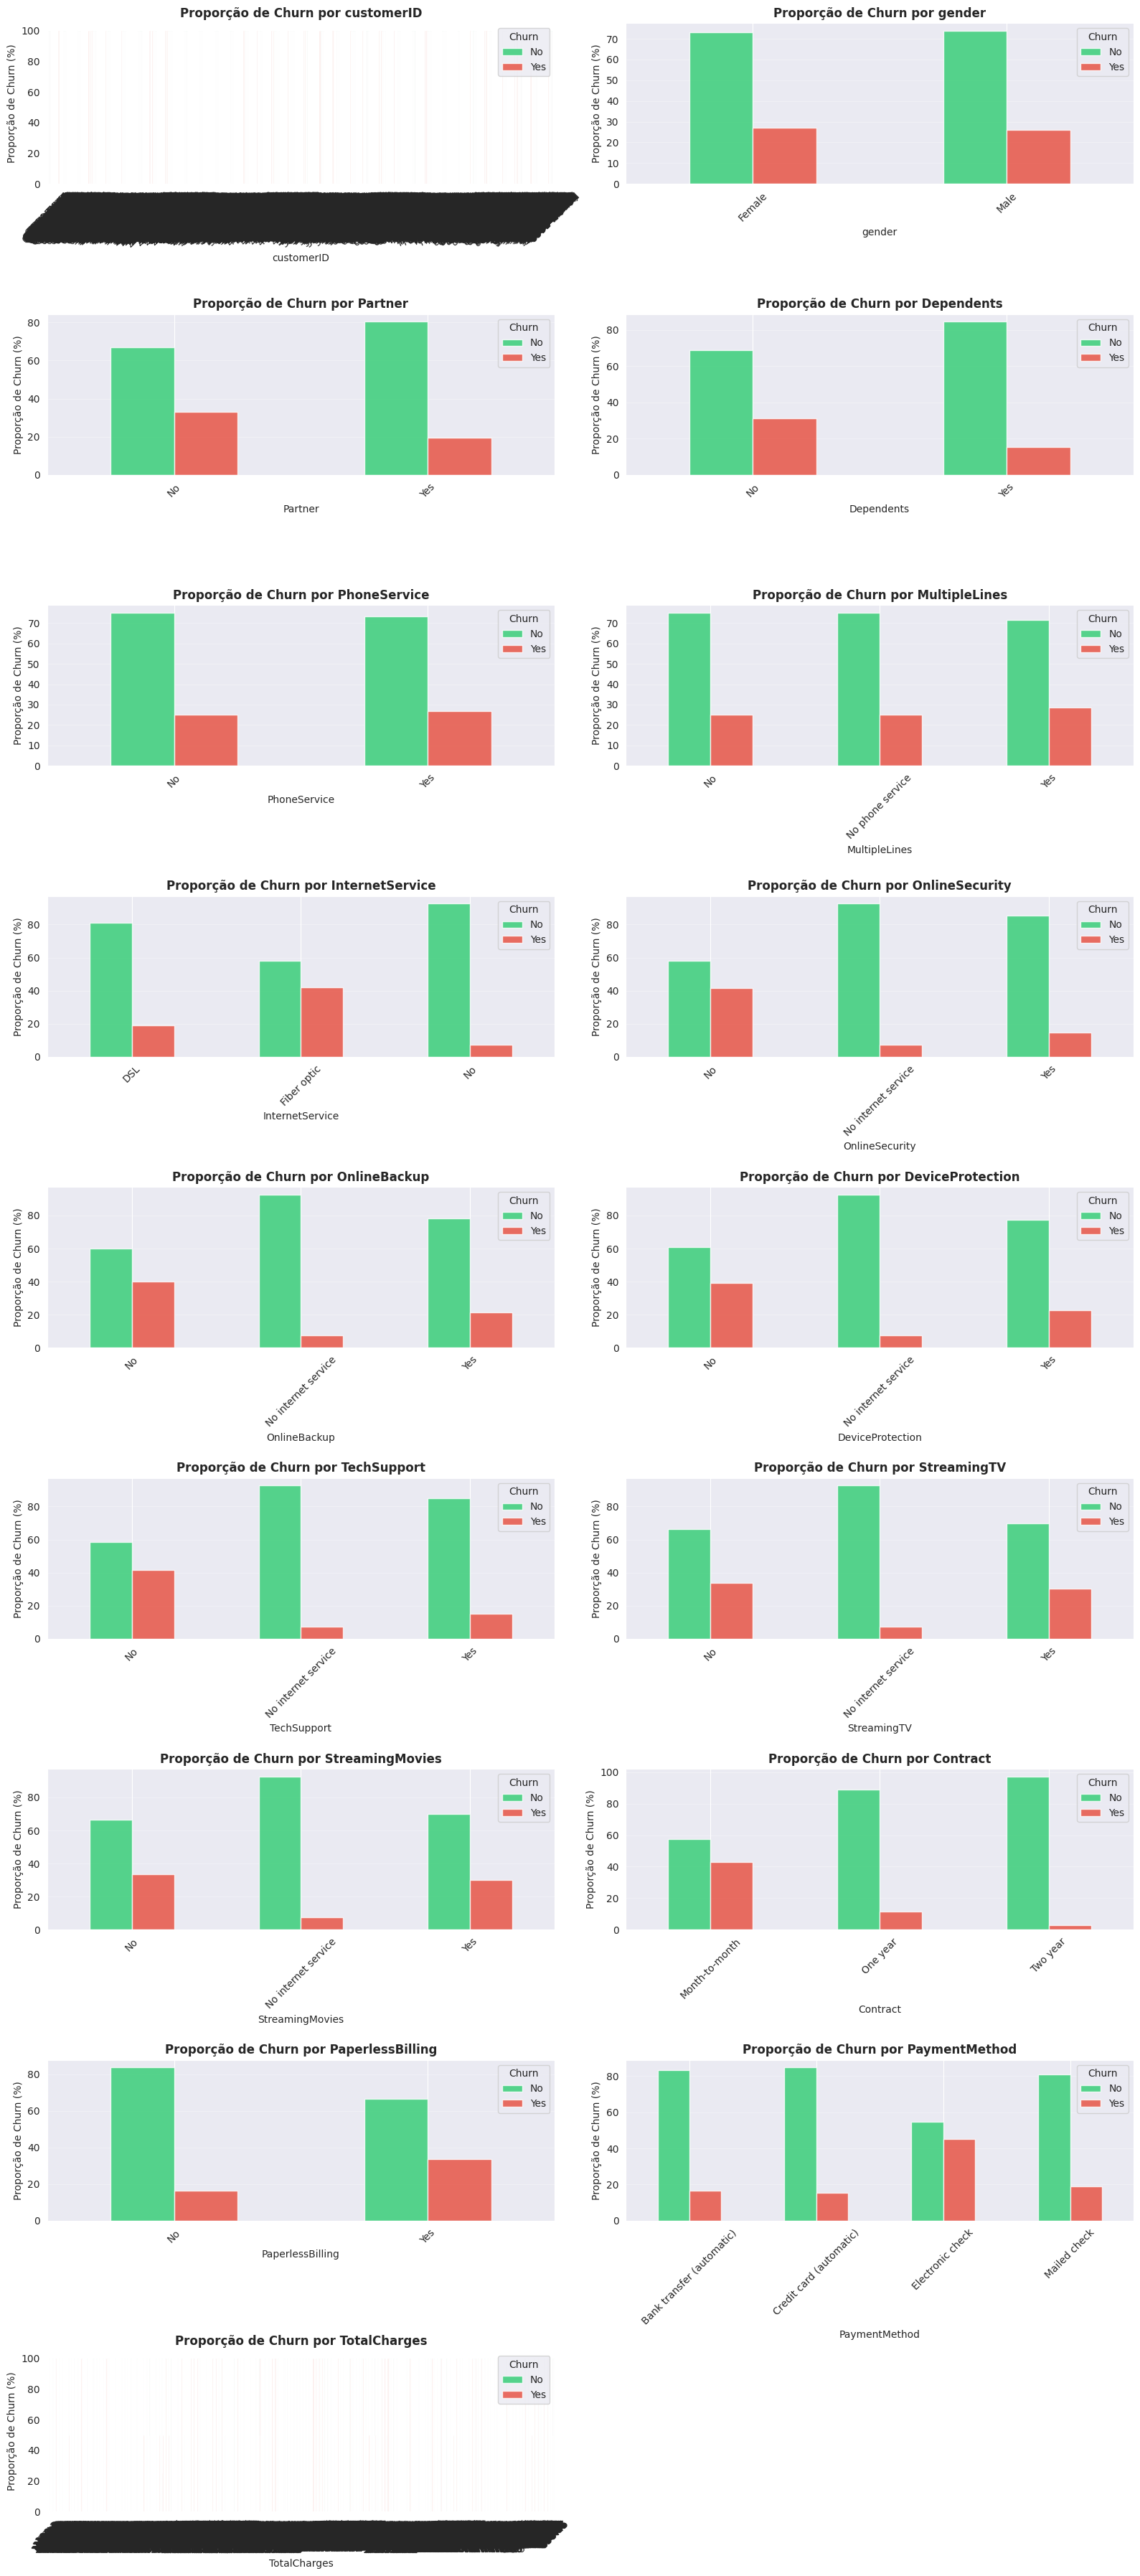

In [9]:
# Analisar relação de variáveis categóricas com Churn
print("\n" + "=" * 80)
print("RELAÇÃO COM CHURN (Variáveis Categóricas)")
print("=" * 80)

fig, axes = plt.subplots((len(categorical_cols) + 1) // 2, 2, 
                         figsize=(16, 4 * ((len(categorical_cols) + 1) // 2)))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    if col != churn_col:
        crosstab = pd.crosstab(df[col], df[churn_col], normalize='index') * 100
        crosstab.plot(kind='bar', ax=axes[idx], color=['#2ecc71', '#e74c3c'], alpha=0.8)
        axes[idx].set_title(f'Proporção de {churn_col} por {col}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel(f'Proporção de {churn_col} (%)')
        axes[idx].tick_params(axis='x', rotation=45)
        axes[idx].legend(title=churn_col, loc='best')
        axes[idx].grid(True, alpha=0.3, axis='y')

# Remover subplots vazios
for idx in range(len(categorical_cols) - 1, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()


In [10]:
# Preparação de Dados para Modelagem
print("\n" + "=" * 80)
print("PREPARAÇÃO DE DADOS")
print("=" * 80)

# Criar cópia do dataframe para transformação
df_model = df.copy()

# Remover colunas que não são úteis
print(f"\nDataset original: {df_model.shape}")

# Identificar colunas a remover (ID, customerID, etc)
cols_to_drop = [col for col in df_model.columns if 'id' in col.lower()]
if cols_to_drop:
    print(f"Removendo colunas: {cols_to_drop}")
    df_model = df_model.drop(columns=cols_to_drop)

print(f"Dataset após remover IDs: {df_model.shape}")

# Converter Churn para binário (0/1)
if churn_col in df_model.columns:
    df_model[churn_col] = (df_model[churn_col] == df[churn_col].unique()[1]).astype(int)
    print(f"\n{churn_col} convertido para binário (0/1)")
    print(f"Distribuição: {df_model[churn_col].value_counts().to_dict()}")

# Verificar tipos de dados após transformação
print(f"\nTipos de dados:\n{df_model.dtypes}")



PREPARAÇÃO DE DADOS

Dataset original: (7043, 21)
Removendo colunas: ['customerID']
Dataset após remover IDs: (7043, 20)

Churn convertido para binário (0/1)
Distribuição: {0: 5174, 1: 1869}

Tipos de dados:
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                 int64
dtype: object


In [11]:
# Encoding de Variáveis Categóricas
print("\n" + "=" * 80)
print("ENCODING DE VARIÁVEIS CATEGÓRICAS")
print("=" * 80)

# Atualizar lista de colunas categóricas após transformações
numeric_features = df_model.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df_model.select_dtypes(include=['object']).columns.tolist()

print(f"\nVariáveis categóricas a codificar: {categorical_features}")

# Label Encoding para variáveis categóricas binárias
label_encoders = {}
binary_features = []

for col in categorical_features:
    unique_values = df_model[col].nunique()
    if unique_values == 2:
        # Variável binária - usar Label Encoding
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df_model[col])
        label_encoders[col] = le
        binary_features.append(col)
        print(f"  {col}: Label Encoded (binárias) - {le.classes_.tolist()}")
    else:
        # Variável com múltiplas categorias - usar One-Hot Encoding
        df_model = pd.get_dummies(df_model, columns=[col], drop_first=True, prefix=col)
        print(f"  {col}: One-Hot Encoded ({unique_values} categorias)")

print(f"\nDataset após encoding: {df_model.shape}")
print(f"\nPrimeiras linhas processadas:\n{df_model.head()}")



ENCODING DE VARIÁVEIS CATEGÓRICAS

Variáveis categóricas a codificar: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']
  gender: Label Encoded (binárias) - ['Female', 'Male']
  Partner: Label Encoded (binárias) - ['No', 'Yes']
  Dependents: Label Encoded (binárias) - ['No', 'Yes']
  PhoneService: Label Encoded (binárias) - ['No', 'Yes']
  MultipleLines: One-Hot Encoded (3 categorias)
  InternetService: One-Hot Encoded (3 categorias)
  OnlineSecurity: One-Hot Encoded (3 categorias)
  OnlineBackup: One-Hot Encoded (3 categorias)
  DeviceProtection: One-Hot Encoded (3 categorias)
  TechSupport: One-Hot Encoded (3 categorias)
  StreamingTV: One-Hot Encoded (3 categorias)
  StreamingMovies: One-Hot Encoded (3 categorias)
  Contract: One-Hot Encoded (3 categorias)
  PaperlessBilling: Lab


NORMALIZAÇÃO DOS DADOS

Features shape: (7043, 6559)
Target shape: (7043,)

Colunas de features:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'TotalCharges_100.2', 'TotalCharges_100.25', 'TotalCharges_100.35', 'TotalCharges_100.4', 'TotalCharges_100.8', 'TotalCharges_100.9', 'TotalCharges_1001.2', 'TotalCharges_1001.5', 

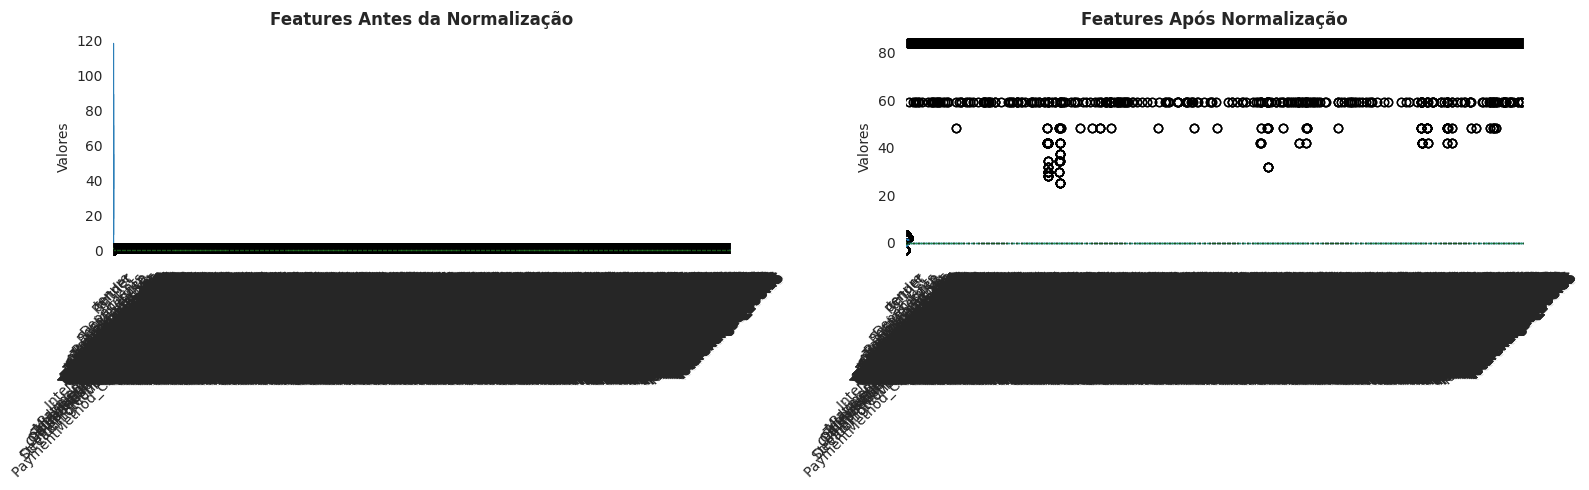

In [12]:
# Normalização (Scaling) dos Dados
print("\n" + "=" * 80)
print("NORMALIZAÇÃO DOS DADOS")
print("=" * 80)

# Separar variável alvo das features
if churn_col in df_model.columns:
    y = df_model[churn_col]
    X = df_model.drop(columns=[churn_col])
else:
    print(f"Aviso: Coluna '{churn_col}' não encontrada após transformações")
    X = df_model
    y = None

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape if y is not None else 'N/A'}")
print(f"\nColunas de features:\n{X.columns.tolist()}")

# Normalizar features numéricas usando StandardScaler
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled = scaler.fit_transform(X_scaled)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(f"\nDados normalizados - Primeiras linhas:\n{X_scaled.head()}")
print(f"\nMédia das features (após normalização):\n{X_scaled.mean()}")
print(f"\nDesvio padrão das features (após normalização):\n{X_scaled.std()}")

# Visualizar distribuição antes e depois da normalização
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Antes
X.boxplot(ax=axes[0])
axes[0].set_title('Features Antes da Normalização', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Valores')
axes[0].tick_params(axis='x', rotation=45)

# Depois
X_scaled.boxplot(ax=axes[1])
axes[1].set_title('Features Após Normalização', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Valores')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



DIVISÃO TREINO/TESTE

Tamanho do conjunto de treino: (5634, 6559)
Tamanho do conjunto de teste: (1409, 6559)

Distribuição de Churn no treino:
Churn
0    4139
1    1495
Name: count, dtype: int64

Proporção no treino:
Churn
0    73.464679
1    26.535321
Name: proportion, dtype: float64

Distribuição de Churn no teste:
Churn
0    1035
1     374
Name: count, dtype: int64

Proporção no teste:
Churn
0    73.456352
1    26.543648
Name: proportion, dtype: float64


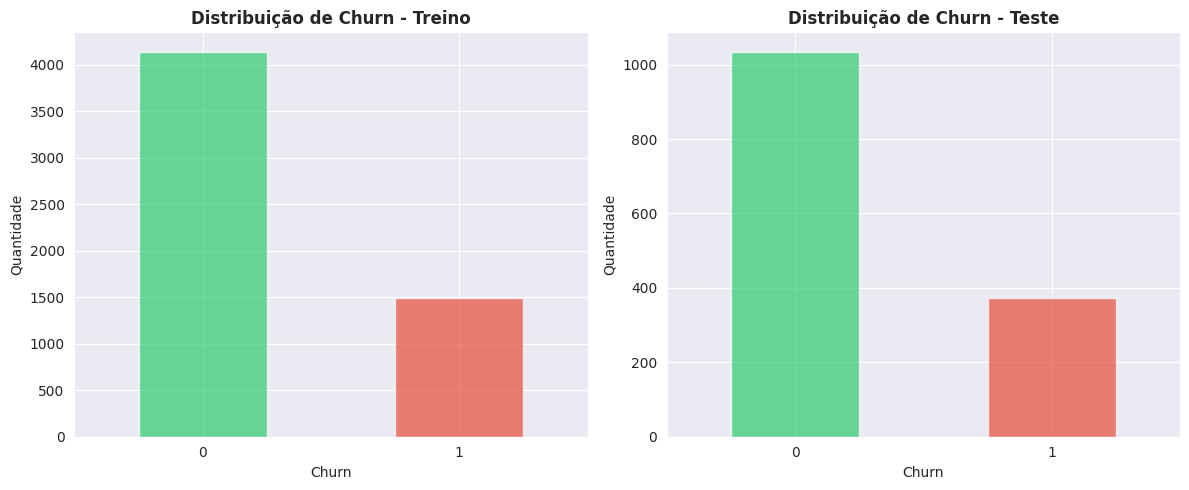


RESUMO FINAL

✓ Dataset originalmente tinha 7043 linhas e 21 colunas
✓ Dataset processado tem 7043 linhas e 6559 features
✓ Dados normalizados e prontos para modelagem
✓ Treino: 5634 amostras | Teste: 1409 amostras


In [13]:
# Divisão Treino/Teste e Salvamento
print("\n" + "=" * 80)
print("DIVISÃO TREINO/TESTE")
print("=" * 80)

# Dividir dados em treino e teste
if y is not None:
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"\nTamanho do conjunto de treino: {X_train.shape}")
    print(f"Tamanho do conjunto de teste: {X_test.shape}")
    
    print(f"\nDistribuição de Churn no treino:")
    print(y_train.value_counts())
    print(f"\nProporção no treino:")
    print(y_train.value_counts(normalize=True) * 100)
    
    print(f"\nDistribuição de Churn no teste:")
    print(y_test.value_counts())
    print(f"\nProporção no teste:")
    print(y_test.value_counts(normalize=True) * 100)
    
    # Visualizar distribuição balanceada
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    y_train.value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], alpha=0.7)
    axes[0].set_title('Distribuição de Churn - Treino', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Quantidade')
    axes[0].tick_params(axis='x', rotation=0)
    
    y_test.value_counts().plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'], alpha=0.7)
    axes[1].set_title('Distribuição de Churn - Teste', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Quantidade')
    axes[1].tick_params(axis='x', rotation=0)
    
    plt.tight_layout()
    plt.show()
    
    # Salvar dados processados
    print("\n" + "=" * 80)
    print("RESUMO FINAL")
    print("=" * 80)
    print(f"\n✓ Dataset originalmente tinha {df.shape[0]} linhas e {df.shape[1]} colunas")
    print(f"✓ Dataset processado tem {X_scaled.shape[0]} linhas e {X_scaled.shape[1]} features")
    print(f"✓ Dados normalizados e prontos para modelagem")
    print(f"✓ Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")
else:
    print("Aviso: Não foi possível processar os dados adequadamente")


In [14]:
# Log com MLflow (Rastreamento de Experimentos)
print("\n" + "=" * 80)
print("RASTREAMENTO COM MLFLOW")
print("=" * 80)

with mlflow.start_run(run_name="eda-preparacao-dados"):
    # Log de parâmetros
    mlflow.log_param("dataset_original_rows", df.shape[0])
    mlflow.log_param("dataset_original_cols", df.shape[1])
    mlflow.log_param("dataset_final_rows", X_scaled.shape[0])
    mlflow.log_param("dataset_final_cols", X_scaled.shape[1])
    mlflow.log_param("train_test_split", "80/20")
    mlflow.log_param("normalizacao", "StandardScaler")
    mlflow.log_param("balanceamento_classes", "stratified")
    
    # Log de métricas
    if y is not None:
        mlflow.log_metric("churn_rate_dataset", y.mean())
        mlflow.log_metric("churn_rate_train", y_train.mean())
        mlflow.log_metric("churn_rate_test", y_test.mean())
        mlflow.log_metric("train_size", X_train.shape[0])
        mlflow.log_metric("test_size", X_test.shape[0])
    
    # Log de tags
    mlflow.set_tag("dataset", "telco_customer_churn")
    mlflow.set_tag("task", "eda_e_preparacao")
    mlflow.set_tag("status", "completo")
    
    print("\n✓ Experimento registrado no MLflow")
    print(f"  - Parâmetros: 7")
    print(f"  - Métricas: 5")
    print(f"  - Run name: eda-preparacao-dados")

print("\n" + "=" * 80)
print("PROCESSO CONCLUÍDO COM SUCESSO!")
print("=" * 80)
print("\n📊 Análise Exploratória: COMPLETA")
print("📈 Visualizações: CRIADAS")
print("🔄 Transformações: APLICADAS")
print("📐 Normalização: REALIZADA")
print("✂️ Divisão Treino/Teste: FEITA")
print("\n✅ Dados prontos para modelagem!")



RASTREAMENTO COM MLFLOW

✓ Experimento registrado no MLflow
  - Parâmetros: 7
  - Métricas: 5
  - Run name: eda-preparacao-dados

PROCESSO CONCLUÍDO COM SUCESSO!

📊 Análise Exploratória: COMPLETA
📈 Visualizações: CRIADAS
🔄 Transformações: APLICADAS
📐 Normalização: REALIZADA
✂️ Divisão Treino/Teste: FEITA

✅ Dados prontos para modelagem!
